<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_4_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd
data = load_iris()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 1.2. Обучите модель KNN

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
param_grid = {'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
grid_clf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 21),
                         'weights': ['uniform', 'distance']})

#### 1.3. Проверьте качество работы модели

In [4]:
from sklearn.metrics import accuracy_score
best_model = grid_clf.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

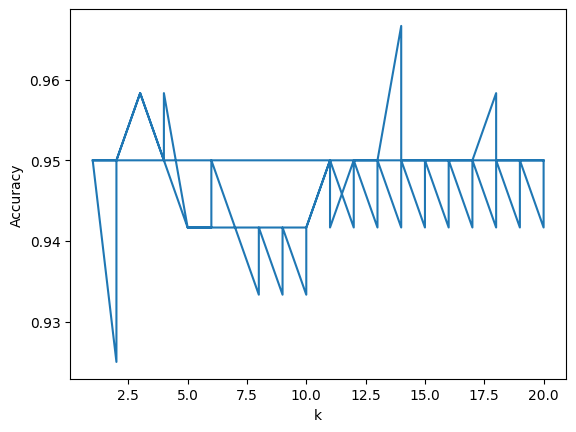

Лучшее k: 14


In [5]:
import matplotlib.pyplot as plt
results = pd.DataFrame(grid_clf.cv_results_)
plt.plot(results['param_n_neighbors'], results['mean_test_score'])
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()
print("Лучшее k:", grid_clf.best_params_['n_neighbors'])

### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [6]:
import numpy as np
X_test_sample = X_test.iloc[:2]
y_test_sample = y_test[:2]

#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [8]:
def euclidean(a, b):
  return np.sqrt(np.sum((a - b) ** 2))
distances_all = []
for test_point in X_test_sample.values:
  distances = []
  for j, train_point in enumerate(X_train.values):
    dist = euclidean(test_point, train_point)
    distances.append((dist, y_train[j]))
  distances_all.append(distances)

#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [9]:
k = grid_clf.best_params_['n_neighbors']
neighbors_all = []
for distances in distances_all:
  distances.sort(key=lambda x: x[0])
  neighbors_all.append(distances[:k])

#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [10]:
predictions = []
for neighbors in neighbors_all:
  classes = [n[1] for n in neighbors]
  pred = max(set(classes), key=classes.count)
  predictions.append(pred)
print("Предсказания:", predictions)

Предсказания: [np.int64(1), np.int64(0)]


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [11]:
print("Истинные:", list(y_test_sample))

Истинные: [np.int64(1), np.int64(0)]


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [12]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

Затем нормализуйте данные:

In [18]:
import pandas as pd
if not isinstance(X_train, pd.DataFrame):
  X_train = pd.DataFrame(X_train, columns=X.columns)
if not isinstance(X_test, pd.DataFrame):
  X_test = pd.DataFrame(X_test, columns=X.columns)
print(X_train.head())

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  0.190322  0.627451  0.029278   0.026601    0.064380  0.002414  0.017021   
1  0.228452  0.941176  0.025419   0.027968    0.036744  0.000842  0.129787   
2  0.252162  0.058824  0.033732   0.025759    0.025561  0.001634  0.224468   
3  0.099488  0.686275  0.022081   0.027683    0.039659  0.002657  0.014894   
4  0.210638  0.823529  0.038147   0.031651    0.024412  0.001294  0.450000   

   Longitude  
0   0.729084  
1   0.616534  
2   0.385458  
3   0.721116  
4   0.453187  


#### 3.2. Обучите модель KNN


In [20]:
from sklearn.neighbors import KNeighborsRegressor
param_grid = {'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)
grid_reg.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 21),
                         'weights': ['uniform', 'distance']})

#### 3.3. Проверьте качество работы модели

In [21]:
from sklearn.metrics import mean_squared_error
best_reg = grid_reg.best_estimator_
pred = best_reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred))

MSE: 0.3576639293963646


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

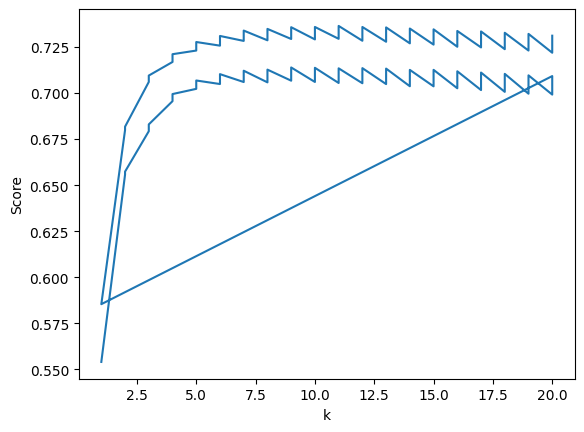

In [22]:
results = pd.DataFrame(grid_reg.cv_results_)
plt.plot(results['param_n_neighbors'], results['mean_test_score'])
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [23]:
import numpy as np
rng = np.random.default_rng(42)
sample_idx_reg = rng.choice(len(X_test), size=2, replace=False)
if isinstance(X_test, pd.DataFrame):
  X_test_sample_reg = X_test.iloc[sample_idx_reg]
else:
  X_test_sample_reg = pd.DataFrame(X_test, columns=X.columns).iloc[sample_idx_reg]
if isinstance(y_test, pd.Series):
  y_test_sample_reg = y_test.iloc[sample_idx_reg]
else:
  y_test_sample_reg = np.array(y_test)[sample_idx_reg]
print("Индексы тестовых объектов:", sample_idx_reg)
print(X_test_sample_reg)

Индексы тестовых объектов: [ 368 3194]
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
368   0.290230  0.372549  0.032847   0.029086    0.057148  0.001477  0.507447   
3194  0.179604  0.019608  0.042467   0.031187    0.003139  0.001332  0.146809   

      Longitude  
368    0.235060  
3194   0.705179  


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [29]:
def euclidean(a, b):
  return np.sqrt(np.sum((a - b) ** 2))
distances_all_reg = []
for test_point in X_test_sample_reg.values:
  distances = []
  for j, train_point in enumerate(X_train.values):
    dist = euclidean(test_point, train_point)
    distances.append((dist, y_train.iloc[j] if hasattr(y_train, 'iloc') else y_train[j]))
  distances_all_reg.append(distances)
print(len(distances_all_reg[0]))

16512


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [31]:
k_reg = grid_reg.best_params_['n_neighbors']
neighbors_all_reg = []
for distances in distances_all_reg:
  distances = sorted(distances, key=lambda x: x[0])
  neighbors_all_reg.append(distances[:k_reg])
neighbors_all_reg[0][:5]

[(np.float64(0.016874192186889354), np.float64(3.962)),
 (np.float64(0.02210769956692232), np.float64(2.642)),
 (np.float64(0.026746347743166806), np.float64(2.5)),
 (np.float64(0.028088747282119943), np.float64(2.625)),
 (np.float64(0.030624505304266893), np.float64(2.273))]

#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [33]:
manual_reg_predictions = []
for neighbors in neighbors_all_reg:
  values = [value for _, value in neighbors]
  manual_reg_predictions.append(float(np.mean(values)))
print(manual_reg_predictions)

[2.516818181818181, 1.8361827272727274]


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [34]:
print("Истинные значения:", list(np.array(y_test_sample_reg)))
print("Предсказания модели sklearn:", list(best_reg.predict(X_test_sample_reg)))

Истинные значения: [np.float64(2.177), np.float64(1.648)]
Предсказания модели sklearn: [np.float64(2.7567814830805064), np.float64(1.6106297092109048)]


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [37]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [38]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [39]:
X = X.iloc[:, [0, 3]].copy()
X.columns = ['sepal length (cm)', 'petal width (cm)']
X.head()

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2


### Визуализируйте ваши данные на графике

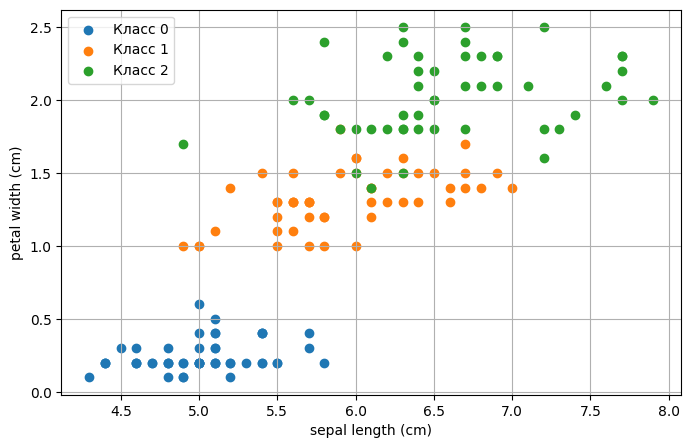

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for cls in sorted(np.unique(y)):
  plt.scatter(X.loc[np.array(y) == cls, 'sepal length (cm)'], X.loc[np.array(y) == cls, 'petal width (cm)'], label=f'Класс {cls}')
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.grid(True)
plt.show()

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [46]:
from sklearn.model_selection import train_test_split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train_cls.shape, X_test_cls.shape)

(120, 2) (30, 2)


#### 1.2. Обучите модель KNN на 50 соседях

In [48]:
from sklearn.neighbors import KNeighborsClassifier
knn_cls = KNeighborsClassifier(n_neighbors=50)
knn_cls.fit(X_train_cls, y_train_cls)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [63]:
from sklearn.metrics import accuracy_score
y_pred_cls = knn_cls.predict(X_test_cls)
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))

Accuracy: 0.8


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [50]:
rng = np.random.default_rng(42)
sample_idx_cls = int(rng.integers(0, len(X_test_cls)))
x_test_one_cls = X_test_cls.iloc[[sample_idx_cls]]
y_test_one_cls = y_test_cls[sample_idx_cls]
distances_cls = []
for j, train_point in enumerate(X_train_cls.values):
  dist = euclidean(x_test_one_cls.values[0], train_point)
  distances_cls.append((dist, y_train_cls[j], j))
distances_cls[:5]

[(np.float64(0.9433981132056605), np.int64(0), 0),
 (np.float64(0.7), np.int64(2), 1),
 (np.float64(1.9416487838947594), np.int64(1), 2),
 (np.float64(0.9), np.int64(0), 3),
 (np.float64(0.6708203932499366), np.int64(1), 4)]

#### 1.5. Выберите топ  k  соседей


In [51]:
neighbors_cls = sorted(distances_cls, key=lambda x: x[0])[:50]
neighbors_cls[:10]

[(np.float64(0.09999999999999964), np.int64(1), 12),
 (np.float64(0.22360679774997838), np.int64(1), 87),
 (np.float64(0.412310562561766), np.int64(0), 83),
 (np.float64(0.49999999999999983), np.int64(1), 37),
 (np.float64(0.5385164807134502), np.int64(0), 71),
 (np.float64(0.5999999999999996), np.int64(1), 24),
 (np.float64(0.6082762530298217), np.int64(1), 76),
 (np.float64(0.6082762530298219), np.int64(0), 27),
 (np.float64(0.6324555320336755), np.int64(1), 65),
 (np.float64(0.6324555320336757), np.int64(0), 30)]

#### 1.6. Выведите финальное предсказание для этого объекта

In [54]:
neighbor_classes = [cls for _, cls, _ in neighbors_cls]
manual_pred_cls = max(set(neighbor_classes), key=neighbor_classes.count)
print(manual_pred_cls)

0


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [55]:
print("Истинный класс:", y_test_one_cls)
print("Предсказание sklearn:", knn_cls.predict(x_test_one_cls)[0])

Истинный класс: 1
Предсказание sklearn: 0


In [56]:
pd.DataFrame(neighbors_cls[:10], columns=['distance', 'class', 'train_index'])

,distance,class,train_index
0,0.100000,1,12
1,0.223607,1,87
2,0.412311,0,83
3,0.500000,1,37
4,0.538516,0,71
5,0.600000,1,24
6,0.608276,1,76
7,0.608276,0,27
8,0.632456,1,65
9,0.632456,0,30


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

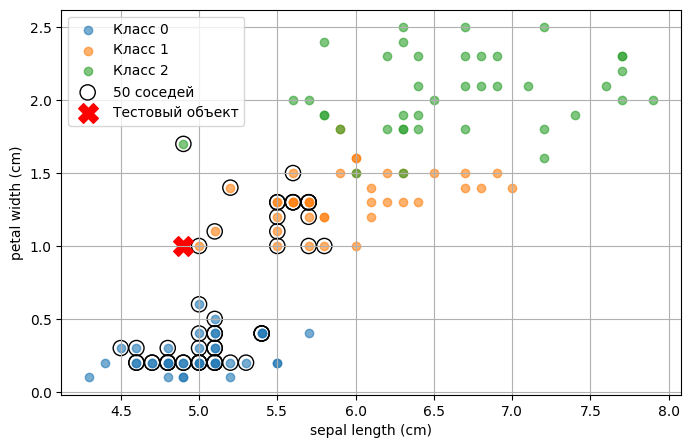

In [60]:
neighbor_indices_cls = [idx for _, _, idx in neighbors_cls]
plt.figure(figsize=(8, 5))
for cls in sorted(np.unique(y_train_cls)):
  mask = np.array(y_train_cls) == cls
  plt.scatter(
      X_train_cls.loc[mask, 'sepal length (cm)'],
      X_train_cls.loc[mask, 'petal width (cm)'],
      label=f'Класс {cls}', alpha=0.6
      )
plt.scatter(
    X_train_cls.iloc[neighbor_indices_cls]['sepal length (cm)'],
    X_train_cls.iloc[neighbor_indices_cls]['petal width (cm)'],
    s=120,
    facecolors='none',
    edgecolors='black',
    label='50 соседей'
    )
plt.scatter(
    x_test_one_cls['sepal length (cm)'],
    x_test_one_cls['petal width (cm)'],
    marker='X',
    s=200,
    c='red',
    label='Тестовый объект'
    )
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.grid(True)
plt.show()

### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [61]:
weighted_knn_cls = KNeighborsClassifier(n_neighbors=50, weights='distance')
weighted_knn_cls.fit(X_train_cls, y_train_cls)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [62]:
weighted_pred_cls = weighted_knn_cls.predict(X_test_cls)
print("Accuracy weighted KNN:", accuracy_score(y_test_cls, weighted_pred_cls))

Accuracy weighted KNN: 0.8666666666666667


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [64]:
weighted_distances_cls = []
for j, train_point in enumerate(X_train_cls.values):
  dist = euclidean(x_test_one_cls.values[0], train_point)
  weighted_distances_cls.append((dist, y_train_cls[j], j))
weighted_distances_cls[:5]

[(np.float64(0.9433981132056605), np.int64(0), 0),
 (np.float64(0.7), np.int64(2), 1),
 (np.float64(1.9416487838947594), np.int64(1), 2),
 (np.float64(0.9), np.int64(0), 3),
 (np.float64(0.6708203932499366), np.int64(1), 4)]

#### 2.4. Выберите топ  k  соседей


In [65]:
weighted_neighbors_cls = sorted(weighted_distances_cls, key=lambda x: x[0])[:50]
weighted_neighbors_cls[:10]

[(np.float64(0.09999999999999964), np.int64(1), 12),
 (np.float64(0.22360679774997838), np.int64(1), 87),
 (np.float64(0.412310562561766), np.int64(0), 83),
 (np.float64(0.49999999999999983), np.int64(1), 37),
 (np.float64(0.5385164807134502), np.int64(0), 71),
 (np.float64(0.5999999999999996), np.int64(1), 24),
 (np.float64(0.6082762530298217), np.int64(1), 76),
 (np.float64(0.6082762530298219), np.int64(0), 27),
 (np.float64(0.6324555320336755), np.int64(1), 65),
 (np.float64(0.6324555320336757), np.int64(0), 30)]

#### 2.5. Рассчитайте вес для каждого соседа

In [66]:
eps = 1e-9
weights_cls = []
for dist, cls, idx in weighted_neighbors_cls:
  w = 1 / (dist + eps)
  weights_cls.append((w, cls, idx))
weights_cls[:10]

[(np.float64(9.999999900000036), np.int64(1), 12),
 (np.float64(4.472135934999591), np.int64(1), 87),
 (np.float64(2.425356244480977), np.int64(0), 83),
 (np.float64(1.9999999960000006), np.int64(1), 37),
 (np.float64(1.8569533783222438), np.int64(0), 71),
 (np.float64(1.66666666388889), np.int64(1), 24),
 (np.float64(1.643989870350871), np.int64(1), 76),
 (np.float64(1.6439898703508704), np.int64(0), 27),
 (np.float64(1.5811388275841904), np.int64(1), 65),
 (np.float64(1.5811388275841902), np.int64(0), 30)]

#### 2.6. Выведите финальное предсказание для этого объекта

In [68]:
from collections import defaultdict
class_weights = defaultdict(float)
for weight, cls, _ in weights_cls:
  class_weights[cls] += weight
manual_weighted_pred_cls = max(class_weights, key=class_weights.get)
print("Рукописное взвешенное предсказание:", manual_weighted_pred_cls)
print("Сумма весов по классам:", dict(class_weights))

Рукописное взвешенное предсказание: 0
Сумма весов по классам: {np.int64(1): np.float64(36.53204816888442), np.int64(0): np.float64(41.69347668939076), np.int64(2): np.float64(1.4285714265306124)}


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [69]:
print("Истинный класс:", y_test_one_cls)
print("Предсказание weighted sklearn:", weighted_knn_cls.predict(x_test_one_cls)[0])

Истинный класс: 1
Предсказание weighted sklearn: 0


In [72]:
pd.DataFrame(weights_cls[:10], columns=['weight', 'class', 'train_index'])

,weight,class,train_index
0,10.000000,1,12
1,4.472136,1,87
2,2.425356,0,83
3,2.000000,1,37
4,1.856953,0,71
5,1.666667,1,24
6,1.643990,1,76
7,1.643990,0,27
8,1.581139,1,65
9,1.581139,0,30


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

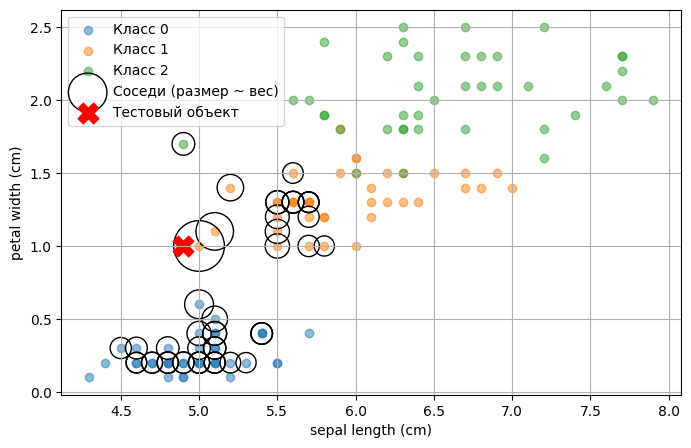

In [77]:
neighbor_indices_wcls = [idx for _, _, idx in weighted_neighbors_cls]
neighbor_distances_wcls = np.array([dist for dist, _, _ in weighted_neighbors_cls])
plt.figure(figsize=(8, 5))
for cls in sorted(np.unique(y_train_cls)):
    mask = np.array(y_train_cls) == cls
    plt.scatter(
        X_train_cls.loc[mask, 'sepal length (cm)'],
        X_train_cls.loc[mask, 'petal width (cm)'],
        label=f'Класс {cls}',
        alpha=0.5
        )
sizes = 200 / (neighbor_distances_wcls + 0.05)
plt.scatter(
    X_train_cls.iloc[neighbor_indices_wcls]['sepal length (cm)'],
    X_train_cls.iloc[neighbor_indices_wcls]['petal width (cm)'],
    s=sizes,
    facecolors='none',
    edgecolors='black',
    label='Соседи (размер ~ вес)'
    )
plt.scatter(
    x_test_one_cls['sepal length (cm)'],
    x_test_one_cls['petal width (cm)'],
    marker='X',
    s=220,
    c='red',
    label='Тестовый объект'
    )
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.grid(True)
plt.show()

## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [76]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = pd.Series(data['target'])
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [78]:
y

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


### Возьмите только признак MedInc и 1000 первых строк

In [80]:
feature_name = 'MedInc' if 'MedInc' in X.columns else X.columns[0]
limit = min(1000, len(X))
X = X[[feature_name]].iloc[:limit].copy()
y = pd.Series(y).iloc[:limit].reset_index(drop=True)
X = X.reset_index(drop=True)
print("Используемый признак:", feature_name)
print("Размер данных:", X.shape)
X.head()

Используемый признак: MedInc
Размер данных: (1000, 1)


,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462


### Отрисуйте данные на графике

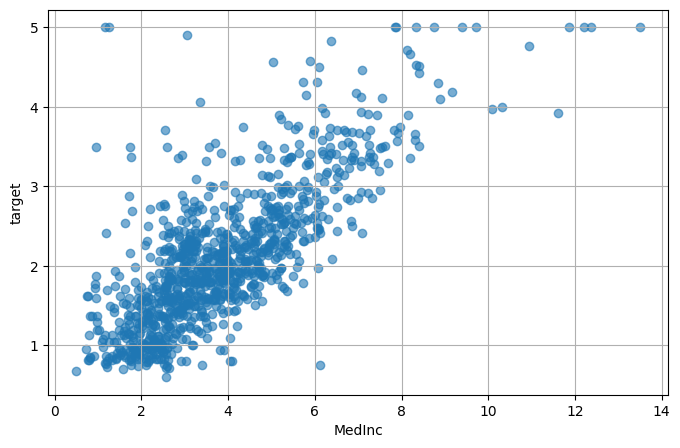

In [81]:
plt.figure(figsize=(8, 5))
plt.scatter(X[feature_name], y, alpha=0.6)
plt.xlabel(feature_name)
plt.ylabel('target')
plt.grid(True)
plt.show()

### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
X_train_reg2, X_test_reg2, y_train_reg2, y_test_reg2 = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_reg2 = MinMaxScaler()
X_train_reg2 = pd.DataFrame(
    scaler_reg2.fit_transform(X_train_reg2),
    columns=[feature_name],
    index=X_train_reg2.index
    )
X_test_reg2 = pd.DataFrame(
    scaler_reg2.transform(X_test_reg2),
    columns=[feature_name],
    index=X_test_reg2.index
    )
print(X_train_reg2.shape, X_test_reg2.shape)

(800, 1) (200, 1)


#### 4.2. Обучите модель KNN на 100 соседях


In [85]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg2 = KNeighborsRegressor(n_neighbors=100)
knn_reg2.fit(X_train_reg2, y_train_reg2)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [86]:
from sklearn.metrics import mean_squared_error
pred_reg2 = knn_reg2.predict(X_test_reg2)
print("MSE:", mean_squared_error(y_test_reg2, pred_reg2))

MSE: 0.2539907243501753


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [87]:
rng = np.random.default_rng(42)
sample_idx_reg2 = int(rng.integers(0, len(X_test_reg2)))
x_test_one_reg = X_test_reg2.iloc[[sample_idx_reg2]]
y_test_one_reg = y_test_reg2.iloc[sample_idx_reg2]
distances_reg2 = []
for j, train_point in enumerate(X_train_reg2.values):
  dist = euclidean(x_test_one_reg.values[0], train_point)
  distances_reg2.append((dist, y_train_reg2.iloc[j], j))
distances_reg2[:10]

[(np.float64(0.23983968120869906), np.float64(1.32), 0),
 (np.float64(0.034994730404412644), np.float64(2.927), 1),
 (np.float64(0.18344346916324977), np.float64(1.375), 2),
 (np.float64(0.02297851389711597), np.float64(2.738), 3),
 (np.float64(0.032132993822649225), np.float64(2.385), 4),
 (np.float64(0.03419467501596263), np.float64(2.593), 5),
 (np.float64(0.20480648660291867), np.float64(2.5), 6),
 (np.float64(0.03274072820426033), np.float64(1.969), 7),
 (np.float64(0.04417228885076663), np.float64(3.769), 8),
 (np.float64(0.059434883953504436), np.float64(1.647), 9)]

#### 4.5. Выберите топ  k  соседей


In [88]:
neighbors_reg2 = sorted(distances_reg2, key=lambda x: x[0])[:100]
neighbors_reg2[:10]

[(np.float64(0.0001230854443768914), np.float64(1.883), 496),
 (np.float64(0.0005615773399696988), np.float64(1.883), 510),
 (np.float64(0.0009154479925532755), np.float64(1.869), 639),
 (np.float64(0.001246240124316289), np.float64(1.86), 716),
 (np.float64(0.001523182374164378), np.float64(2.22), 568),
 (np.float64(0.0018385888253802385), np.float64(2.419), 130),
 (np.float64(0.0019385957489364558), np.float64(2.791), 577),
 (np.float64(0.0021078382349546954), np.float64(3.518), 503),
 (np.float64(0.002546330130547503), np.float64(2.171), 240),
 (np.float64(0.00264633705410372), np.float64(1.563), 154)]

#### 4.6. Выведите финальное предсказание для этого объекта

In [89]:
manual_pred_reg2 = float(np.mean([val for _, val, _ in neighbors_reg2]))
print("Рукописное предсказание:", manual_pred_reg2)

Рукописное предсказание: 2.3538


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [90]:
print("Истинное значение:", float(y_test_one_reg))
print("Предсказание sklearn:", float(knn_reg2.predict(x_test_one_reg)[0]))

Истинное значение: 2.54
Предсказание sklearn: 2.3538


In [91]:
pd.DataFrame(neighbors_reg2[:10], columns=['distance', 'target', 'train_index'])

,distance,target,train_index
0,0.000123,1.883,496
1,0.000562,1.883,510
2,0.000915,1.869,639
3,0.001246,1.860,716
4,0.001523,2.220,568
5,0.001839,2.419,130
6,0.001939,2.791,577
7,0.002108,3.518,503
8,0.002546,2.171,240
9,0.002646,1.563,154


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

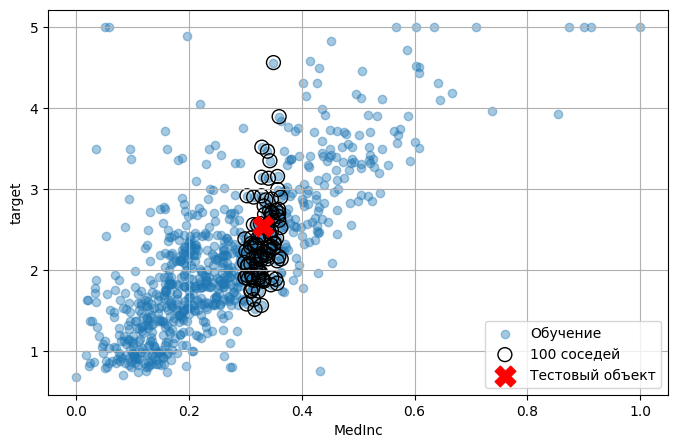

In [93]:
neighbor_indices_reg2 = [idx for _, _, idx in neighbors_reg2]
plt.figure(figsize=(8, 5))
plt.scatter(X_train_reg2[feature_name], y_train_reg2, alpha=0.4, label='Обучение')
plt.scatter(
    X_train_reg2.iloc[neighbor_indices_reg2][feature_name],
    y_train_reg2.iloc[neighbor_indices_reg2],
    s=100,
    facecolors='none',
    edgecolors='black',
    label='100 соседей'
    )
plt.scatter(
    x_test_one_reg[feature_name],
    [y_test_one_reg],
    marker='X',
    s=220,
    c='red',
    label='Тестовый объект'
    )
plt.xlabel(feature_name)
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.show()

### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [94]:
weighted_knn_reg2 = KNeighborsRegressor(n_neighbors=100, weights='distance')
weighted_knn_reg2.fit(X_train_reg2, y_train_reg2)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели


In [95]:
weighted_pred_reg2 = weighted_knn_reg2.predict(X_test_reg2)
print("MSE weighted KNN:", mean_squared_error(y_test_reg2, weighted_pred_reg2))

MSE weighted KNN: 0.3078943245850898


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [98]:
weighted_distances_reg2 = []
for j, train_point in enumerate(X_train_reg2.values):
  dist = euclidean(x_test_one_reg.values[0], train_point)
  weighted_distances_reg2.append((dist, y_train_reg2.iloc[j], j))
weighted_distances_reg2[:10]

[(np.float64(0.23983968120869906), np.float64(1.32), 0),
 (np.float64(0.034994730404412644), np.float64(2.927), 1),
 (np.float64(0.18344346916324977), np.float64(1.375), 2),
 (np.float64(0.02297851389711597), np.float64(2.738), 3),
 (np.float64(0.032132993822649225), np.float64(2.385), 4),
 (np.float64(0.03419467501596263), np.float64(2.593), 5),
 (np.float64(0.20480648660291867), np.float64(2.5), 6),
 (np.float64(0.03274072820426033), np.float64(1.969), 7),
 (np.float64(0.04417228885076663), np.float64(3.769), 8),
 (np.float64(0.059434883953504436), np.float64(1.647), 9)]

#### 5.4. Выберите топ  k  соседей


In [99]:
weighted_neighbors_reg2 = sorted(weighted_distances_reg2, key=lambda x: x[0])[:100]
weighted_neighbors_reg2[:10]

[(np.float64(0.0001230854443768914), np.float64(1.883), 496),
 (np.float64(0.0005615773399696988), np.float64(1.883), 510),
 (np.float64(0.0009154479925532755), np.float64(1.869), 639),
 (np.float64(0.001246240124316289), np.float64(1.86), 716),
 (np.float64(0.001523182374164378), np.float64(2.22), 568),
 (np.float64(0.0018385888253802385), np.float64(2.419), 130),
 (np.float64(0.0019385957489364558), np.float64(2.791), 577),
 (np.float64(0.0021078382349546954), np.float64(3.518), 503),
 (np.float64(0.002546330130547503), np.float64(2.171), 240),
 (np.float64(0.00264633705410372), np.float64(1.563), 154)]

#### 5.5. Рассчитайте вес для каждого соседа

In [100]:
eps = 1e-9
weights_reg2 = [(1 / (dist + eps), target, idx) for dist, target, idx in weighted_neighbors_reg2]
weights_reg2[:10]

[(np.float64(8124.371494053353), np.float64(1.883), 496),
 (np.float64(1780.695459254994), np.float64(1.883), 510),
 (np.float64(1092.3601512858772), np.float64(1.869), 639),
 (np.float64(802.4129363798828), np.float64(1.86), 716),
 (np.float64(656.5197710017039), np.float64(2.22), 568),
 (np.float64(543.8951016674914), np.float64(2.419), 130),
 (np.float64(515.8370354993195), np.float64(2.791), 577),
 (np.float64(474.4194829552518), np.float64(3.518), 503),
 (np.float64(392.72190015011273), np.float64(2.171), 240),
 (np.float64(377.88067115963645), np.float64(1.563), 154)]

#### 5.6. Выведите финальное предсказание для этого объекта

In [103]:
numerator = sum(weight * target for weight, target, _ in weights_reg2)
denominator = sum(weight for weight, _, _ in weights_reg2)
manual_weighted_pred_reg2 = float(numerator / denominator)
print(manual_weighted_pred_reg2)

2.1437756511426955


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [104]:
print("Истинное значение:", float(y_test_one_reg))
print("Предсказание weighted sklearn:", float(weighted_knn_reg2.predict(x_test_one_reg)[0]))

Истинное значение: 2.54
Предсказание weighted sklearn: 2.1437748694492873


In [105]:
pd.DataFrame(weights_reg2[:10], columns=['weight', 'target', 'train_index'])

,weight,target,train_index
0,8124.371494,1.883,496
1,1780.695459,1.883,510
2,1092.360151,1.869,639
3,802.412936,1.860,716
4,656.519771,2.220,568
5,543.895102,2.419,130
6,515.837035,2.791,577
7,474.419483,3.518,503
8,392.721900,2.171,240
9,377.880671,1.563,154


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

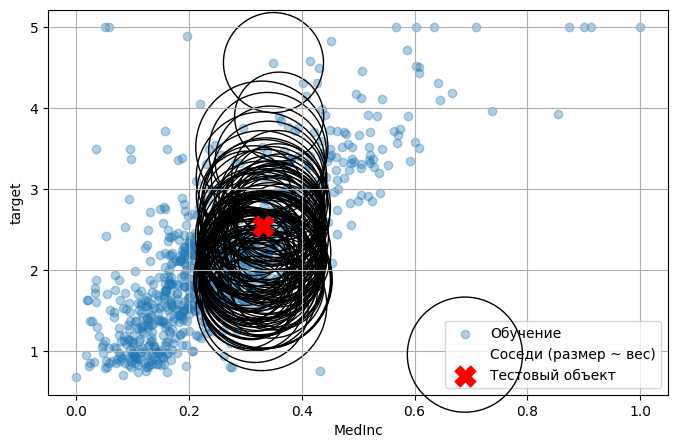

In [107]:
neighbor_indices_wreg2 = [idx for _, _, idx in weighted_neighbors_reg2]
neighbor_distances_wreg2 = np.array([dist for dist, _, _ in weighted_neighbors_reg2])
plt.figure(figsize=(8, 5))
plt.scatter(X_train_reg2[feature_name], y_train_reg2, alpha=0.35, label='Обучение')
sizes = 200 / (neighbor_distances_wreg2 + 0.02)
plt.scatter(
    X_train_reg2.iloc[neighbor_indices_wreg2][feature_name],
    y_train_reg2.iloc[neighbor_indices_wreg2],
    s=sizes,
    facecolors='none',
    edgecolors='black',
    label='Соседи (размер ~ вес)'
    )
plt.scatter(
    x_test_one_reg[feature_name],
    [y_test_one_reg],
    marker='X',
    s=220,
    c='red',
    label='Тестовый объект'
    )
plt.xlabel(feature_name)
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.show()

## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [110]:
param_grid_last = {
    'n_neighbors': [5, 10, 20, 50, 100],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
    }
grid_last = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_last,
    cv=5,
    scoring='neg_mean_squared_error'
    )
grid_last.fit(X_train_reg2, y_train_reg2)
print("Лучшие параметры:", grid_last.best_params_)
print("Лучший CV MSE:", -grid_last.best_score_)
best_last_model = grid_last.best_estimator_
best_last_pred = best_last_model.predict(X_test_reg2)
print("MSE на тесте:", mean_squared_error(y_test_reg2, best_last_pred))

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 50, 'weights': 'uniform'}
Лучший CV MSE: 0.3556943938113638
MSE на тесте: 0.2437865607890872
